In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Analysis

In [ ]:
from src.experiments_analysis.plots_ismb import model_name_replacement_dict
from pathlib import Path as P
all_seeds = [44, 36, 546]

output_dir = "results/benchmark_destriping_model/simulation_big_with_struct_nb_weibul_2__all_seeds/analysis_glum_benchmark_v3/2026-18-01/19-22-00"

supp_publi_output_folder = "results/publication_oup_v2/simulation_brain_all_seeds/supp"
main_publi_output_folder = "results/publication_oup_v2/simulation_brain_all_seeds/main"

P(main_publi_output_folder).mkdir(exist_ok=True, parents=True)
P(supp_publi_output_folder).mkdir(exist_ok=True, parents=True)
P(output_dir).mkdir(exist_ok=True, parents=True)

config_dicts = {seed: P("experiments/benchmark_output_files/synthetic_data")/f"seed_{seed}.yaml" for seed in all_seeds}

In [ ]:
from src.experiments_analysis.analysis_simulated_data_pipeline import analysis
import pandas as pd
import yaml


for seed in all_seeds[1:]:

    print(f"SEED {seed}")
    cfg = yaml.safe_load(open(config_dicts[seed]))

    seed_output_dir = cfg["output_dir"]
    runs = cfg["runs"]
    dividing_by_ratio_baselines = cfg["dividing_by_ratio_baselines"]
    not_factor_based_baseline = cfg["not_factor_based_baseline"]
    supp_baselines_dir = cfg["supp_baselines_dir"]

    analysis(
        seed_output_dir,
        runs,
        dividing_by_ratio_baselines,
        not_factor_based_baseline,
        supp_baselines_dir,
    )

## Tables/Plots for paper

In [7]:
name_error_in_corrected_counts = "Cosine error in $k^{corr}$"
name_error_in_stripe_factors = "Log-space L2 error in $(\mathbf{h}, \mathbf{w})$"

In [ ]:
from src.experiments_analysis.analysis import filter_summary_df_qm
from pathlib import Path as P
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from src.utilities.pandas import save_latex
import yaml

df_list = []

# --- configuration ---
metrics = {
    "distance_to_gt_poisson_sol_hw_log_euclidian": name_error_in_stripe_factors,
    "cosine_distance_to_gt_take_n_counts_adjusted=True_nucleus_only=True": name_error_in_corrected_counts,
}
method_order = [
    "original",
    "b2c",
    "bin-level norm.",
    "b2c-sym",
    "b2c-sym-nucl", 
    "b2c-sym-med",
    "b2c-sym-med-nucl",
    "MRSE",
    "ours",
    "ours_P2.I",
    "ours_N.I"
]

spread_kind = "std"

for seed in all_seeds:
    cfg = yaml.safe_load(open(config_dicts[seed]))
    output_dir = P(cfg["output_dir"])

    poisson_summary_df_path = output_dir / "poisson_summary_df.pkl"
    poisson_summary_df = pd.read_pickle(poisson_summary_df_path)

    destriped_data_df_path = (
        output_dir
        / "distance_destriped_data/gt_destriping_method='qm'/destriped_data_df.pkl"
    )
    destriped_data_df = pd.read_pickle(destriped_data_df_path)
    destriped_data_df = filter_summary_df_qm(destriped_data_df)

    df_all = pd.merge(
        poisson_summary_df,
        destriped_data_df,
        on="name",
        how="inner",
        suffixes=("", "_drop"),
    )
    df_all["name"] = df_all["name"].replace(model_name_replacement_dict)

    # keep seed so we can aggregate later
    df_all["seed"] = seed

    print(df_all.columns)

    table_seed = (
        df_all[["name", "dataset_path", "seed", *metrics.keys()]]
        .rename(columns=metrics)
        .loc[df_all["name"].isin(method_order)]
    )

    df_list.append(table_seed)

table_long = pd.concat(df_list, ignore_index=True)

table_long_path = P(supp_publi_output_folder) / "table_long.parquet"
table_long.to_parquet(table_long_path, index=False)

group_cols = ["dataset_path", "name"]
value_cols = list(metrics.values())

agg = table_long.groupby(group_cols)[value_cols].agg(["mean", "std", "count"])


for col in value_cols:
    agg[(col, "se")] = agg[(col, "std")] / np.sqrt(agg[(col, "count")])


spread_stat = "std" if spread_kind == "std" else "se"

def fmt_pm(mean, spread):
    if pd.isna(mean):
        return "-"
    if pd.isna(spread):
        return f"{mean:.3g}"
    return rf"{mean:.3g} $\pm$ {spread:.2g}"


formatted = pd.DataFrame(index=agg.index)
for col in value_cols:
    formatted[col] = [
        fmt_pm(m, s) for m, s in zip(agg[(col, "mean")], agg[(col, spread_stat)])
    ]

table_pm = (
    formatted.unstack("dataset_path")
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1, level=0)
)

table_pm = table_pm.reindex(method_order)

display(HTML(table_pm.to_html(escape=False)))


# --- LaTeX export ---
def preprocess(df):
    df = df.transpose()
    df.columns.name = None
    df.index.name = None
    return df


latex_kwargs = {
    "index_names": False,
    "bold_rows": True,
    "na_rep": "-",
    "escape": False,  # IMPORTANT: allow $\pm$
}

latex_table_path = P(supp_publi_output_folder) / "distance_all_pm.txt"
save_latex(preprocess(table_pm), latex_table_path, width=r"\textwidth", **latex_kwargs)

csv_table_path = P(supp_publi_output_folder) / "distance_all_pm.csv"
table_pm.to_csv(csv_table_path)


main_methods = [
    "b2c",
    "b2c-sym",
    "ours",
    "original",
]
table_pm_main = table_pm.loc[main_methods]

display(HTML(table_pm_main.to_html(escape=False)))

latex_table_path = P(main_publi_output_folder) / "distance_all_pm.txt"
save_latex(
    preprocess(table_pm_main), latex_table_path, width=r"\textwidth", **latex_kwargs
)

csv_table_path = P(main_publi_output_folder) / "distance_all_pm.csv"
table_pm_main.to_csv(csv_table_path)

/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:1155: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:1155: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:1155: FutureW

Index(['name', 'dataset_path', 'cell_id_label', 'poisson_sol_path',
       'time_dict', 'status_dict', 'overrides', 'config', 'run_dir',
       'sweep_folder', 'subdir', 'fitting_args', 'fitting_time',
       'destripe_time', 'theta_iter_', 'theta_iter_converged_', 'converged',
       'glm_path', 'dist', 'dist_params', 'glm', 'alpha', 'theta', 'n_iter',
       'destriping_method', 'destriped_data_path', 'binned_data_path',
       'radius', 'cell_typing', 'distance_to_gt_poisson_sol_h_cosine',
       'distance_to_gt_poisson_sol_h_euclidian',
       'distance_to_gt_poisson_sol_h_log_euclidian',
       'distance_to_gt_poisson_sol_w_cosine',
       'distance_to_gt_poisson_sol_w_euclidian',
       'distance_to_gt_poisson_sol_w_log_euclidian',
       'distance_to_gt_poisson_sol_f_cosine',
       'distance_to_gt_poisson_sol_f_euclidian',
       'distance_to_gt_poisson_sol_f_log_euclidian',
       'distance_to_gt_poisson_sol_hw_euclidian',
       'distance_to_gt_poisson_sol_hw_log_euclidian',


## Plots

### Barplots distance to GT

/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:9: FutureWarning:



The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'grey'}` instead.


/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:17: FutureWarning:



The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'grey'}` instead.




['ours', 'original', 'b2c-sym']
Categories (3, object): ['b2c-sym' < 'ours' < 'original']


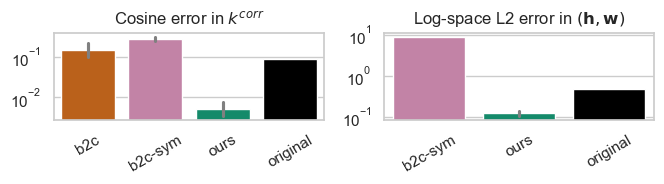

/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:9: FutureWarning:



The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'grey'}` instead.


/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:17: FutureWarning:



The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'grey'}` instead.




['ours', 'ours_P2.I', 'ours_N.I', 'original', 'MRSE', 'b2c-sym-med', 'b2c-sym-med-nucl', 'b2c-sym-nucl', 'b2c-sym']
Categories (9, object): ['original' < 'b2c-sym' < 'b2c-sym-nucl' < 'b2c-sym-med' ... 'MRSE' < 'ours' < 'ours_P2.I' < 'ours_N.I']


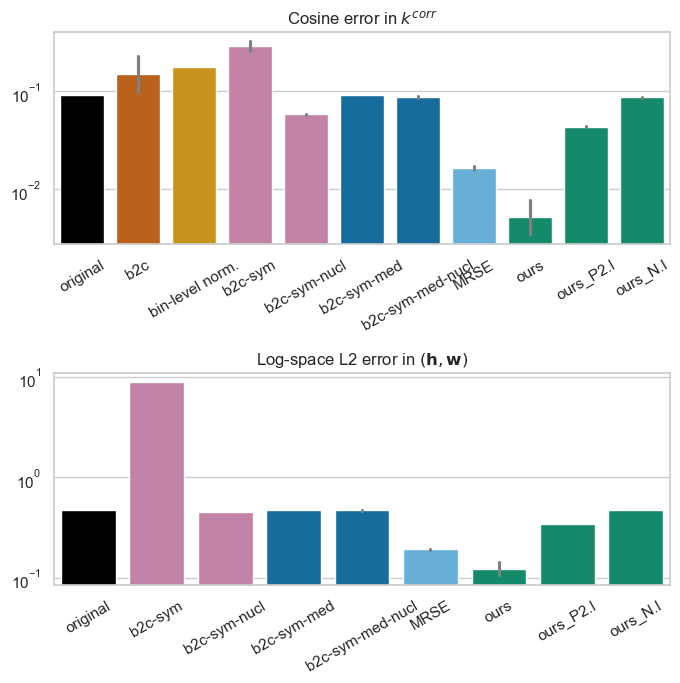

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path as P
from src.experiments_analysis.plots_ismb import color_dict
from src.experiments_analysis.analysis_plots import barplots_distance_to_gt

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(1, 2, figsize=(3.4 * 2, 2))
barplots_distance_to_gt(
    table_long,
    main_methods,
    color_dict,
    name_error_in_corrected_counts,
    name_error_in_stripe_factors,
    P(main_publi_output_folder) / "distance_all.pdf",
    axes=axes,
)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(7, 7))
barplots_distance_to_gt(
    table_long,
    method_order,
    color_dict,
    name_error_in_corrected_counts,
    name_error_in_stripe_factors,
    P(supp_publi_output_folder) / "distance_all.pdf",
    axes=axes,
)

plt.show()

### Zoom illustration

In [ ]:
from src.experiments_analysis.analysis import destriped_data_plots
from matplotlib.colors import PowerNorm

to_plot = ["original", "GT"]
global_structure_analysis_folder = "/Users/pmalsot/Documents/ETH/BMI/ST-Project/bin2cell_broken/results/benchmark_destriping_model/simulation_big_with_struct_nb_weibul_2/analysis_glum_benchmark_v3/2026-01-01/18-26-00/global_structure_analysis"
destriped_data_plots(global_structure_analysis_folder)


/Users/pmalsot/Documents_no_iCloud/bin2cell/src/utilities/cv2_utils.py:25: RuntimeWarning:

invalid value encountered in divide

/Users/pmalsot/Documents_no_iCloud/bin2cell/src/utilities/cv2_utils.py:25: RuntimeWarning:

invalid value encountered in cast



Using vmin, vmax = 0.0 205.0


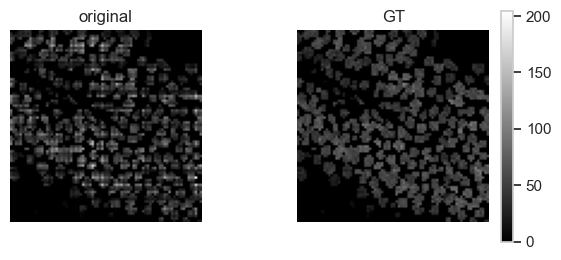

In [ ]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots,
)

to_plot = ["original", "GT"]
global_structure_analysis_folder = "results/benchmark_destriping_model/simulation_big_with_struct_nb_weibul_2/analysis_glum_benchmark_v3/2026-01-01/18-26-00/global_structure_analysis"
region_slice = (slice(1020, 1100), slice(2050, 2130))

fig, axes = plt.subplots(1, 2, figsize=(3.4 * 2, 3))

axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    region_slice,
    model_name_replacement_dict,
    axes=axes,
    colorbar_same_scale=True,
)
[ax.axis("off") for ax in axes]

for cax in np.array(fig.axes).flatten():
    if (cax.get_label() != "<colorbar>") and (cax.get_title() != "GT"):
        cax.get_images()[0].colorbar.ax.set_visible(False)

### Panel for simulated data

Using vmin, vmax = 0.0 205.0
['ours', 'original', 'b2c-sym']
Categories (3, object): ['b2c-sym' < 'ours' < 'original']


/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:9: FutureWarning:



The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'grey'}` instead.


/Users/pmalsot/Documents_no_iCloud/bin2cell/src/experiments_analysis/analysis_simulated_data_funs.py:17: FutureWarning:



The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'grey'}` instead.




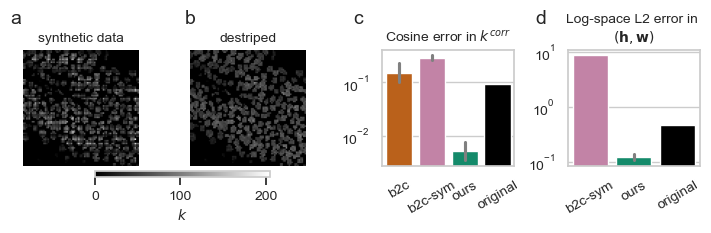

In [ ]:
from matplotlib.gridspec import GridSpec
from src.utilities.matplotlib_utils import save_pdf_temp_intermediate


name_original = "synthetic data"
name_GT = "destriped"
panel_output_path = (
    "results/publication_oup_v2/figures/panels/panel_simulation.pdf"
)

fig = plt.figure(layout="constrained", figsize=(7.009, 2.1))
gs = GridSpec(
    1, 4, width_ratios=[1, 1, 1, 1], hspace=0.2, figure=fig, left=0.2, right=0.8, bottom = 0, top = 0.7
)

base_font_size = 10
base_font_size = 10
plt.rcParams.update(
    {
        "font.size": base_font_size,  # base font size
        "axes.labelsize": base_font_size,  # x/y label size
        "axes.titlesize": base_font_size,  # title size
        "xtick.labelsize": base_font_size,  # x tick labels
        "ytick.labelsize": base_font_size,  # y tick labels
        "legend.fontsize": base_font_size,  # legend
    }
)

# destriped VS GT example
axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]

axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    region_slice,
    model_name_replacement_dict,
    axes=axes,
    colorbar_same_scale=True,
)
[ax.axis("off") for ax in axes]
axes[0].set_title(name_original)
axes[1].set_title(name_GT)

for ax in axes:
    if ax.images and getattr(ax.images[0], "colorbar", None) is not None:
        ax.images[0].colorbar.ax.set_visible(False)
fig.canvas.draw()

pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
left = pos0.x0
right = pos1.x1
bottom = min(pos0.y0, pos1.y0)
top = max(pos0.y1, pos1.y1)
width = (right - left) * 0.5
mappable = axes[0].images[0]
cax = fig.add_axes([left + width / 2, bottom + 0.07, width, 0.03])
cbar = fig.colorbar(mappable, cax=cax, orientation="horizontal")
cbar.set_label(r"$k$")

axes = [
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]),
]
barplots_distance_to_gt(
    table_long,
    main_methods,
    color_dict,
    name_error_in_corrected_counts,
    name_error_in_stripe_factors,
    P(main_publi_output_folder) / "distance_all.pdf",
    axes=axes,
)

axes[1].set_title(
    name_error_in_stripe_factors.replace("Log-space L2 error in ", "Log-space L2 error in \n")
)

letters_fontsize = 14
fig.text(0.01, 1, "a", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.26, 1, "b", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.5, 1, "c", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.76, 1, "d", ha="left", va="top", fontsize=letters_fontsize)

save_pdf_temp_intermediate("temp_outputs", panel_output_path, dpi=300, bbox_inches = "tight")

plt.show()

### Global structure plot

In [18]:
# distance to original
distance_to_original_table_list = []
for seed in all_seeds:
    cfg = yaml.safe_load(open(config_dicts[seed]))
    seed_output_dir = P(cfg["output_dir"])
    seed_global_dir_path = seed_output_dir / "global_structure_analysis"

    distance_to_original_smoothed_path = (
            P(seed_global_dir_path)
            / "plots_global_structure"
            / "statistics_global_structure.csv"
        )
    distance_to_original_smoothed_table = pd.read_csv(
        distance_to_original_smoothed_path
    )
    distance_to_original_table_list.append(distance_to_original_smoothed_table)

distance_to_original_table = pd.concat(distance_to_original_table_list)
distance_to_original_table_gp = (
    distance_to_original_table.groupby(
        ["axis", "lane_name", "operation_name", "ref", "comp"]
    )
    .agg(difference=("difference", "mean"), difference__std=("difference", "std"))
    .reset_index()
)
all_seeds_global_dir_path = P(output_dir) / "global_structure_analysis"
all_seeds_global_dir_path.mkdir(exist_ok=True, parents=True)
distance_to_original_smoothed_path = (
    P(all_seeds_global_dir_path)
    / "plots_global_structure"
    / "statistics_global_structure.csv"
)
distance_to_original_smoothed_path.parent.mkdir(exist_ok=True, parents=True)
distance_to_original_table_gp.to_csv(distance_to_original_smoothed_path)

for cyto in [True, False]:
    striping_intensity_table_list = []

    for seed in all_seeds:
        cfg = yaml.safe_load(open(config_dicts[seed]))
        seed_output_dir = P(cfg["output_dir"])
        seed_global_dir_path = seed_output_dir / "global_structure_analysis"

        if not cyto:
            striping_intensity_table_path = (
                P(seed_global_dir_path) / "striping_intensity" / "striping_intensity_statistics.csv"
            )

        else:
            striping_intensity_table_path = (
                P(seed_global_dir_path)
                / "cyto_striping_intensity"
                / "cyto_striping_intensity_statistics.csv"
            )

        striping_intensity_table = pd.read_csv(striping_intensity_table_path)

        striping_intensity_table_list.append(striping_intensity_table)

    striping_intensity_table = pd.concat(striping_intensity_table_list)
    distance_to_original_table = pd.concat(distance_to_original_table_list)

    striping_intensity_table_gp = (
        striping_intensity_table.drop(columns = ["index_in_df_results", "path_destriped_n_counts_matrix"]).groupby(
            ["name"]
        )
        .agg(["mean", "std"])
        .reset_index()
    )
    striping_intensity_table_gp.columns = [
        f"{c}__{f}" if (f and (f != "mean")) else c for c, f in striping_intensity_table_gp.columns
    ]

    if not cyto:
        striping_intensity_table_path = (
            P(all_seeds_global_dir_path)
            / "striping_intensity"
            / "striping_intensity_statistics.csv"
        )
    else:
        striping_intensity_table_path = (
            P(all_seeds_global_dir_path)
            / "cyto_striping_intensity"
            / "cyto_striping_intensity_statistics.csv"
        )

    print(striping_intensity_table_gp.columns)

    striping_intensity_table_gp.to_csv(striping_intensity_table_path)

Index(['name', 'striping_intensity_row', 'striping_intensity_row__std',
       'striping_intensity_column', 'striping_intensity_column__std',
       'striping_intensity_tot', 'striping_intensity_tot__std', 'Unnamed: 0',
       'Unnamed: 0__std', 'striping_intensity_row__std',
       'striping_intensity_row__std__std', 'striping_intensity_column__std',
       'striping_intensity_column__std__std', 'striping_intensity_tot__std',
       'striping_intensity_tot__std__std'],
      dtype='object')
Index(['name', 'striping_intensity_row', 'striping_intensity_row__std',
       'striping_intensity_column', 'striping_intensity_column__std',
       'striping_intensity_tot', 'striping_intensity_tot__std', 'Unnamed: 0',
       'Unnamed: 0__std', 'striping_intensity_row__std',
       'striping_intensity_row__std__std', 'striping_intensity_column__std',
       'striping_intensity_column__std__std', 'striping_intensity_tot__std',
       'striping_intensity_tot__std__std'],
      dtype='object')


striping intensity in cytoplasm + nucleus
yo


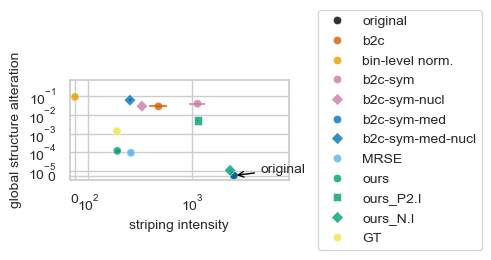

In [98]:
from src.experiments_analysis.analysis_simulated_data_funs import (
    compromise_striping_intensity_global_structure_alteration,
)
from src.experiments_analysis.plots_ismb import color_dict

to_plot = method_order + ["GT"]

markers_dict = {
    "b2c-sym-nucl": "D",
    "b2c-sym-med-nucl": "D",
    "ours_N.I": "D",
    "ours_P2.I": "s",
}
markers_dict_n = {key: markers_dict.get(key, "o") for key in to_plot}
markers_dict = markers_dict_n

axis = compromise_striping_intensity_global_structure_alteration(
    False,
    all_seeds_global_dir_path,
    main_publi_output_folder,
    model_name_replacement_dict,
    offset_dict=None,
    to_plot=to_plot,
    annotation=False,
    colors=color_dict,
    markers=markers_dict,
    alpha = 0.8
)

striping_intensity_table_path = (
        P(all_seeds_global_dir_path) / "striping_intensity" / "striping_intensity_statistics.csv"
    )
striping_intensity_table = pd.read_csv(striping_intensity_table_path)
striping_intensity_table["name"] = striping_intensity_table["name"].replace(model_name_replacement_dict)

distance_to_original_smoothed_path = (
        P(all_seeds_global_dir_path) / "plots_global_structure" / "statistics_global_structure.csv"
    )
distance_to_original_smoothed_table = pd.read_csv(distance_to_original_smoothed_path)
distance_to_original_smoothed_table["comp"] = (
    distance_to_original_smoothed_table["comp"].replace(model_name_replacement_dict)
)
for method in to_plot:
    distance_to_original_smoothed_table_sel = distance_to_original_smoothed_table.query(
        "(lane_name == 'rowscolumns') and "
        "(operation_name == 'sum') and "
        "(ref == 'original')"
    )

    std_distance_to_original = distance_to_original_smoothed_table_sel.set_index(
        "comp"
    ).loc[method, "difference__std"]

    distance_to_original = distance_to_original_smoothed_table_sel.set_index("comp").loc[method, "difference"]

    std_striping_intensity = striping_intensity_table.query("name == @method")[
        "striping_intensity_tot__std"
    ]

    striping_intensity = striping_intensity_table.query("name == @method")[
        "striping_intensity_tot"
    ]

    x = float(striping_intensity.iloc[0]) if hasattr(striping_intensity, "iloc") else float(striping_intensity)
    xerr = float(std_striping_intensity.iloc[0]) if hasattr(std_striping_intensity, "iloc") else float(std_striping_intensity)

    y = float(distance_to_original)
    yerr = float(std_distance_to_original)

    axis.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",                 # no marker; just the cross
        ecolor=color_dict.get(method, "black"),
        elinewidth=1.2,
        capsize=0,                  # keep it as a clean cross (no caps)
        alpha=0.9,
        zorder=10,
    )

    if method == "original":
        print("yo")
        axis.annotate(
            "original",
            xy=(x, y),  # arrow tip (points here)
            xytext=(x*1.5, y*1.5),  # text position (and arrow tail anchor)
            arrowprops=dict(arrowstyle="->", lw=1, color = "black"),
            ha="left",
            va="bottom",
        )

axis.grid("on")
path_figure = P(main_publi_output_folder) / "striping_intensity-global_structure_alteration.pdf"
plt.savefig(path_figure)